In [11]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import pandas as pd

# M1

In [12]:
root = Path("../../data/intent_sessions_full.parquet")
df = pl.read_parquet(str(root))
#считаю Effort по формуле Effort = log1p(n_unique_queries) + log1p(n_view) + log1p(duration_s)
Effort = pl.col("n_unique_queries").log1p() + pl.col("n_view").log1p() + pl.col("duration_s").log1p()
#считаю IRS по формуле IRS = 1/(1+Effort)
IRS = 1 / (1 + Effort)
#записываю в новый датафрейм и сохраняю в новую таблицу
df_res = df.with_columns([
    Effort.alias("Effort"),
    IRS.alias("IRS")
])
path_of_intent_sessions_scored = Path("../../data/intent_sessions_scored.parquet")
df_res.write_parquet(path_of_intent_sessions_scored)

In [63]:
df.columns

Index(['user_id', 'session_idx', 'ts_start', 'ts_end', 'n_events', 'n_search',
       'n_view', 'n_click', 'n_cart', 'n_fav', 'n_unique_queries',
       'first_query', 'first_widget', 'n_unique_categories',
       'top_category_in_session', 'duration_s', 'reached_cart',
       'ts_first_cart', 'time_to_cart_s', 'category'],
      dtype='object')

# M2 Query Depth: baseline

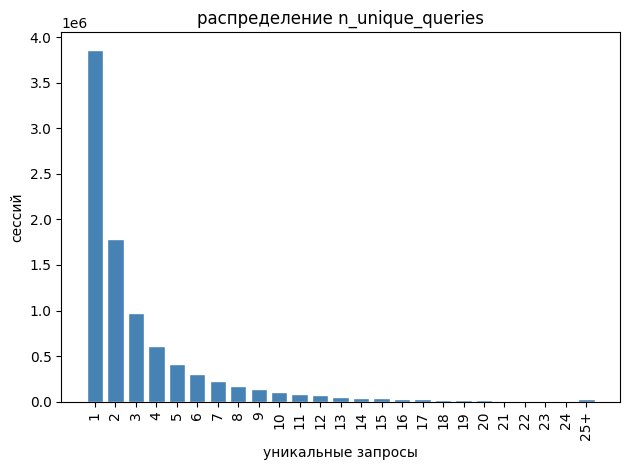

Медиана: 2.0
Среднее: 3.287315309362147 P95: 10.0 Max: 99225


In [13]:
import numpy as np

# Данные сильно скошены, режем хвост
CLIP = 25
data = df_res['n_unique_queries'].to_numpy()

counts = np.bincount(np.clip(data, 1, CLIP), minlength=CLIP + 1)
labels = [str(i) for i in range(1, CLIP)] + [f'{CLIP}+']
values = list(counts[1:CLIP]) + [counts[CLIP:].sum()]

# Bar chart
plt.bar(labels, values, color='steelblue', edgecolor='white')
plt.title('распределение n_unique_queries')
plt.xlabel('уникальные запросы')
plt.ylabel('сессий')
plt.xticks(rotation=90)


plt.tight_layout()
plt.savefig('../../docs/n_unique_queries_dist.png', dpi=150)
plt.show()
print("Медиана:", np.median(data))
print("Среднее:", data.mean(), "P95:", np.percentile(data, 95), "Max:", data.max())

In [61]:
#разбитие по бинам и расчет конверсии в корзину для каждой бины
df_ex =df_res.with_columns(
    pl.col('n_unique_queries').cut([1, 2, 5, 10, 15, 20], labels=['1','2','3-5','6-10','10-15','15-20','20+']).alias('query_bucket')
).group_by('query_bucket').agg(
    pl.col('reached_cart').mean().alias('cart_rate')
).sort('query_bucket')
df_ex

query_bucket,cart_rate
enum,f64
"""1""",0.252343
"""2""",0.411526
"""3-5""",0.667082
"""6-10""",0.906612
"""10-15""",0.971935
"""15-20""",0.985587
"""20+""",0.988155


In [ ]:
#корреляция с M1
df_res.select(
    pl.corr('n_unique_queries', 'IRS')
)
#около 0, хотя вклад есть, все портит log1p

n_unique_queries
f64
-0.016695


# M3

In [14]:
#распределяем категории по колонке топовой категории в сессии, отсекаем в other все что меньше 200 сессий
MIN_SIZE = 200
large_cats = (
      df.group_by("top_category_in_session")
      .agg(pl.len().alias("n"))
      .filter(pl.col("n") >= MIN_SIZE)
      .get_column("top_category_in_session")
      .to_list()
  )
df = df.with_columns(
      pl.when(pl.col("top_category_in_session").is_in(large_cats))
        .then(pl.col("top_category_in_session"))
        .otherwise(pl.lit("__other__"))
        .alias("category")
)
#тренируем KaplanMeierFitter для каждой категории и сохраняем в словарь, чтобы потом не пересчитывать при каждом запросе
kmf_by_cat = {}
theDF = df.select(['duration_s', 'reached_cart', 'category']).to_pandas()

for cat, group in theDF.groupby("category"):
      kmf = KaplanMeierFitter()
      kmf.fit(durations=group["duration_s"], event_observed=group["reached_cart"], label=cat)
      kmf_by_cat[cat] = kmf


In [ ]:
#заполняем заранее значения S(t) для всех категорий, чтобы потом не пересчитывать при каждом запросе
unreached_pdf = theDF[theDF["reached_cart"] == False]

records = []
for cat, group in unreached_pdf.groupby("category"):
    kmf = kmf_by_cat.get(cat, kmf_by_cat["__other__"])
    unique_ts = group["duration_s"].unique()
    sf_values = kmf.survival_function_at_times(unique_ts).values
    for t, s in zip(unique_ts, sf_values):
        records.append({"category": cat, "duration_s": int(t), "S_t": float(s)})

survival_lookup = pl.DataFrame(records)

In [ ]:
#считаем метрику 
df_scored = (
    df
    .join(survival_lookup, on=["category", "duration_s"], how="left")
    .with_columns(
        pl.when(pl.col("reached_cart"))
          .then(-pl.col("time_to_cart_s").log1p())
          .otherwise(-(1 - pl.col("S_t")))
          .alias("time_to_cart_score")
    )
)
#краткое описание распределения метрики
df_scored.select("time_to_cart_score").describe()

statistic,time_to_cart_score
str,f64
"""count""",9.031454e6
"""null_count""",0.0
"""mean""",-1.621227
"""std""",1.908396
"""min""",-9.477998
"""25%""",-2.995732
"""50%""",-0.541867
"""75%""",-0.029074
"""max""",-0.0


# M4

In [30]:
from  sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import OneHotEncoder
from catboost import CatBoostClassifier

In [31]:
def timesort(frame): #cортировка по времени
  frame['ts_start'] = pd.to_datetime(frame['ts_start'], format='%Y-%m-%d %H:%M:%S')
  frame.sort_values('ts_start', inplace=True)
  return frame

In [ ]:
def M4_lift(cart_feat, P_cart):
    lift = cart_feat / P_cart
    return lift

In [32]:
df = timesort(df.to_pandas()).reset_index(drop=True)

AttributeError: 'DataFrame' object has no attribute 'to_pandas'

In [41]:
#выделяю признаки и таргет
int_features = ['n_unique_queries', 'n_view','duration_s','n_search','n_click']#'duration_s' - можно добавить
categorical_features = ['first_widget', 'category']#чтобы работало с category надо прогнать 1 ячейку M3

X = df[int_features + categorical_features]
y = df['reached_cart']

In [42]:
#сплит с учетом времени
n = len(df)
train_end = int(n * 0.6)
cal_end   = int(n * 0.8)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_cal, y_cal = X.iloc[train_end:cal_end], y.iloc[train_end:cal_end]
X_val, y_val = X.iloc[cal_end:], y.iloc[cal_end:]

In [ ]:
P_cart = df['reached_cart'].mean()
print(f"Доля сессий, в которых был достигнут cart: {P_cart:.4f}")

Доля сессий, в которых был достигнут cart: 0.4798


In [24]:
#пробуем лог регрссию
#OneHotEncoder для категориальных признаков, объединяю с числовыми и обучаю модель, оцениваю на валидации
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_train = encoder.fit_transform(X_train[categorical_features])
cat_cal   = encoder.transform(X_cal[categorical_features])
cat_val   = encoder.transform(X_val[categorical_features])

X_train_enc = np.hstack([X_train[int_features].values, cat_train])
X_cal_enc   = np.hstack([X_cal[int_features].values,   cat_cal])
X_val_enc   = np.hstack([X_val[int_features].values,   cat_val])
#модель
model = LogisticRegression(max_iter=200, solver='saga', verbose=1)
model.fit(X_train_enc, y_train)
#оценка
auc = roc_auc_score(y_val, model.predict_proba(X_val_enc)[:, 1])
print(f"ROC AUC (val): {auc:.4f}")
print(f"train: {len(X_train):,}  cal: {len(X_cal):,}  val: {len(X_val):,}")
#на 100 итерациях ~0.74, change <0.009 на шаге, 
# на 200 итерациях, ~0.78, change < 0.004
# на 500 не дождался,берет 10+мин, мб стоит эксперментировать с solver и регуляризацией))

KeyboardInterrupt: 

In [43]:
# пробуем catboost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=50  # печатать каждые 50 итераций
)

model.fit(
    X_train, y_train,
    cat_features=categorical_features,  # категориальные колонки — catboost сам их кодирует
    eval_set=(X_cal, y_cal),
    early_stopping_rounds=50        # остановить если нет улучшения
)
#можно дорабатывать гиперпараметры, но и так гуд

0:	learn: 0.6566924	test: 0.6559212	best: 0.6559212 (0)	total: 1.66s	remaining: 13m 50s
50:	learn: 0.4109140	test: 0.4092159	best: 0.4092159 (50)	total: 35s	remaining: 5m 7s
100:	learn: 0.3951486	test: 0.3929090	best: 0.3929090 (100)	total: 1m 8s	remaining: 4m 30s
150:	learn: 0.3887727	test: 0.3862277	best: 0.3862277 (150)	total: 1m 45s	remaining: 4m 4s
200:	learn: 0.3855153	test: 0.3828664	best: 0.3828664 (200)	total: 2m 21s	remaining: 3m 29s
250:	learn: 0.3833415	test: 0.3806913	best: 0.3806913 (250)	total: 2m 54s	remaining: 2m 52s
300:	learn: 0.3817597	test: 0.3791249	best: 0.3791249 (300)	total: 3m 26s	remaining: 2m 16s
350:	learn: 0.3806347	test: 0.3779620	best: 0.3779620 (350)	total: 3m 58s	remaining: 1m 41s
400:	learn: 0.3797693	test: 0.3770801	best: 0.3770801 (400)	total: 4m 34s	remaining: 1m 7s
450:	learn: 0.3790542	test: 0.3763596	best: 0.3763596 (450)	total: 5m 5s	remaining: 33.2s
499:	learn: 0.3784262	test: 0.3757211	best: 0.3757211 (499)	total: 5m 36s	remaining: 0us

bestT

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, verbose=50)

In [44]:
#оценка кэтбуста
auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
print(f"ROC AUC (val): {auc:.4f}")
print(f"train: {len(X_train):,}  cal: {len(X_cal):,}  val: {len(X_val):,}")
#Вывод катбуст лучше, вопрос остается в интерпретируемости

ROC AUC (val): 0.9093
train: 5,418,872  cal: 1,806,291  val: 1,806,291


In [50]:
from sklearn.metrics import brier_score_loss
score = brier_score_loss(y_val, model.predict_proba(X_val)[:, 1])
print(f"Brier score: {score:.4f}")#оцениваем качество колибровки до изотонической регрессии

Brier score: 0.1223


In [46]:
from sklearn.isotonic import IsotonicRegression

# скоры на cal выборке от уже обученного CatBoost
cal_scores = model.predict_proba(X_cal)[:, 1]

# фитим изотоническую регрессию на cal
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(cal_scores, y_cal)

# калиброванные вероятности на val
val_scores = model.predict_proba(X_val)[:, 1]
val_proba_calibrated = iso.predict(val_scores)

auc = roc_auc_score(y_val, val_proba_calibrated)
print(f"ROC AUC после калибровки: {auc:.4f}")

ROC AUC после калибровки: 0.9093


In [ ]:
score = brier_score_loss(y_val, val_proba_calibrated)
print(f"Brier score: {score:.4f}")# почти не отличается от некалиброванного, мб стоит рассмотреть ее откидывание


Brier score: 0.1221


In [ ]:
model.predict_proba(df[int_features + categorical_features])[:, 1]

df['M4'] = 

0.25      15.0
0.50      74.0
0.75     344.0
0.95    1608.0
Name: duration_s, dtype: float64

In [62]:
df.columns

Index(['user_id', 'session_idx', 'ts_start', 'ts_end', 'n_events', 'n_search',
       'n_view', 'n_click', 'n_cart', 'n_fav', 'n_unique_queries',
       'first_query', 'first_widget', 'n_unique_categories',
       'top_category_in_session', 'duration_s', 'reached_cart',
       'ts_first_cart', 'time_to_cart_s', 'category'],
      dtype='object')